# AA200 Problem Set 4 — Problem 2
## Viscous Flow Over NACA 2410 Airfoil
### Hess-Smith Panel Method + Thwaites/Head BL + Michel's Transition
**Re_c = 5×10⁶, α = 1°, N = 160 panels**

The Hess-Smith implementation is a **direct Python translation** of previous MATLAB code  
(`naca4.m`, `panel_geometry.m`, `infl_coeff.m`, `veldis.m`, `aero_coeff.m`).

**Two-step procedure (no inviscid-viscous coupling):**
1. Hess-Smith → $V_e(s)$, $dV_e/ds$ on upper and lower surfaces
2. Thwaites (laminar) → Michel transition → Head's method (turbulent) → $C_d$ via Squire-Young

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

plt.rcParams.update({'figure.dpi': 120, 'font.size': 12,
                     'lines.linewidth': 2, 'axes.grid': True, 'grid.alpha': 0.35})

---
## 1. NACA 4-digit Geometry — `naca4.m` (Python translation)



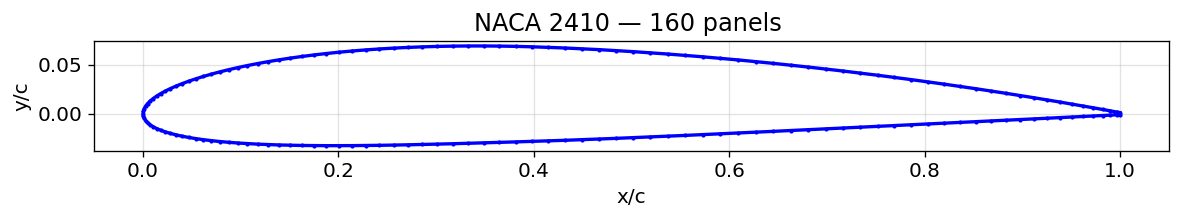

Nodes: 161,  Panels: 160


In [38]:
def naca4(naca4_digits, npanel):
    """
    Building a NACA profile
    """
    n1 = naca4_digits % 10
    n2 = (naca4_digits % 100) // 10
    n3 = (naca4_digits % 1000) // 100
    n4 = (naca4_digits % 10000) // 1000
    m = n4 / 100.0;  p = n3 / 10.0;  t = (n2*10 + n1) / 100.0

    if npanel % 2 != 0: raise ValueError('Even number of panels required')
    nside = npanel // 2 + 1
    an = 1.5;  anp = an + 1.0

    xx = np.zeros(nside);  yt = np.zeros(nside);  yc = np.zeros(nside)
    for i in range(nside):
        f = i / (nside - 1)
        xx[i] = 1 - anp*f*(1-f)**an - (1-f)**anp
        yt[i] = (0.29690*np.sqrt(xx[i]) - 0.12600*xx[i] - 0.35160*xx[i]**2
                 + 0.28430*xx[i]**3 - 0.10150*xx[i]**4) * t / 0.20
        yc[i] = (m/p**2*(2*p*xx[i] - xx[i]**2) if xx[i] < p
                 else m/(1-p)**2*((1-2*p) + 2*p*xx[i] - xx[i]**2))

    x = np.zeros(npanel + 1);  y = np.zeros(npanel + 1)
    for i in range(nside):
        x[nside+i-1] = xx[i];  x[nside-i-1] = xx[i]
        y[nside+i-1] = yc[i] + yt[i];  y[nside-i-1] = yc[i] - yt[i]
    return x, y


N_panels = 160
x_foil, y_foil = naca4(2410, N_panels)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x_foil, y_foil, 'b.-', ms=3)
ax.set_aspect('equal');  ax.set_xlabel('x/c');  ax.set_ylabel('y/c')
ax.set_title(f'NACA 2410 — {N_panels} panels ')
plt.tight_layout();  plt.show()
print(f'Nodes: {len(x_foil)},  Panels: {N_panels}')

---
## 2. Hess-Smith Panel Method

Direct Python translation of `panel_geometry.m`, `infl_coeff.m`, `veldis.m`, `aero_coeff.m`.

**Formulation:**
- $N$ panels, each with uniform source strength $q_i$
- Single global vortex $\gamma$ (constant, enforces Kutta condition)
- $(N+1)\times(N+1)$ linear system: $N$ flow-tangency + 1 Kutta
- Influence coefficients use $\ln(r_{i,j+1}/r_{i,j})$ and $\beta_{ij} = \text{atan2}(...)$

In [39]:
def panel_geometry(x, y, npanel):
    """Translation of panel_geometry.m"""
    l = np.zeros(npanel);  st = np.zeros(npanel);  ct = np.zeros(npanel)
    xbar = np.zeros(npanel);  ybar = np.zeros(npanel)
    for i in range(npanel):
        l[i]    = np.sqrt((x[i+1]-x[i])**2 + (y[i+1]-y[i])**2)
        st[i]   = (y[i+1]-y[i]) / l[i]
        ct[i]   = (x[i+1]-x[i]) / l[i]
        xbar[i] = 0.5*(x[i+1]+x[i])
        ybar[i] = 0.5*(y[i+1]+y[i])
    return l, st, ct, xbar, ybar


def infl_coeff(x, y, xbar, ybar, st, ct, npanel):
    """Translation of infl_coeff.m — builds (N+1)x(N+1) influence matrix"""
    p2 = 1.0/(2*np.pi)
    ainfl = np.zeros((npanel+1, npanel+1))
    cosdt = np.zeros((npanel, npanel));  sindt = np.zeros((npanel, npanel))
    lns   = np.zeros((npanel, npanel));  betas = np.zeros((npanel, npanel))

    for i in range(npanel):
        for j in range(npanel):
            cosdt[i,j] = ct[i]*ct[j] + st[i]*st[j]
            sindt[i,j] = st[i]*ct[j] - st[j]*ct[i]
            if i == j:
                lns[i,j] = 0.0;  betas[i,j] = np.pi
            else:
                r1 = np.sqrt((xbar[i]-x[j  ])**2 + (ybar[i]-y[j  ])**2)
                r2 = np.sqrt((xbar[i]-x[j+1])**2 + (ybar[i]-y[j+1])**2)
                lns[i,j]   = np.log(r2 / r1)
                betas[i,j] = np.arctan2(
                    (ybar[i]-y[j+1])*(xbar[i]-x[j]) - (xbar[i]-x[j+1])*(ybar[i]-y[j]),
                    (xbar[i]-x[j+1])*(xbar[i]-x[j]) + (ybar[i]-y[j+1])*(ybar[i]-y[j]))

    for i in range(npanel):
        for j in range(npanel):
            ainfl[i,j] = p2*(sindt[i,j]*lns[i,j] + cosdt[i,j]*betas[i,j])
        ainfl[i, npanel] = p2*np.sum(cosdt[i,:]*lns[i,:] - sindt[i,:]*betas[i,:])

    # Kutta condition: panels 0 (lower TE) and npanel-1 (upper TE)
    for j in range(npanel):
        s = sum(sindt[k,j]*betas[k,j] - cosdt[k,j]*lns[k,j] for k in [0, npanel-1])
        ainfl[npanel, j] = p2 * s
    ainfl[npanel, npanel] = p2 * sum(
        np.sum(sindt[k,:]*lns[k,:] + cosdt[k,:]*betas[k,:]) for k in [0, npanel-1])

    return ainfl, cosdt, sindt, lns, betas


def veldis(qg, cosdt, sindt, lns, betas, st, ct, al, npanel):
    """Translation of veldis.m — tangential velocity at each panel midpoint"""
    p2 = 1.0/(2*np.pi);  vt = np.zeros(npanel);  gamma = qg[npanel]
    for i in range(npanel):
        vt[i] = ct[i]*np.cos(al) + st[i]*np.sin(al)
        for j in range(npanel):
            vt[i] += p2*qg[j]   * (sindt[i,j]*betas[i,j] - cosdt[i,j]*lns[i,j])
            vt[i] += p2*gamma   * (sindt[i,j]*lns[i,j]   + cosdt[i,j]*betas[i,j])
    return vt


def aero_coeff(x, y, cp, al, npanel):
    """Translation of aero_coeff.m — cl, cd, cm about c/4"""
    cl = cd = cm = 0.0
    for i in range(npanel):
        dx = x[i+1]-x[i];  dy = y[i+1]-y[i]
        xa = 0.5*(x[i+1]+x[i]) - 0.25;  ya = 0.5*(y[i+1]+y[i])
        dcl = -cp[i]*dx;  dcd = cp[i]*dy
        cl += dcl;  cd += dcd;  cm += dcd*ya - dcl*xa
    dcl = cl*np.cos(al) - cd*np.sin(al)
    cd  = cl*np.sin(al) + cd*np.cos(al)
    return dcl, cd, cm


def hess_smith(naca4_digits, alpha_deg, npanel):
    """Full Hess-Smith solver — Python translation of hess_smith.m"""
    x, y = naca4(naca4_digits, npanel)
    l, st, ct, xbar, ybar = panel_geometry(x, y, npanel)
    ainfl, cosdt, sindt, lns, betas = infl_coeff(x, y, xbar, ybar, st, ct, npanel)

    al = np.radians(alpha_deg)
    b  = np.zeros(npanel + 1)
    for i in range(npanel):
        b[i] = st[i]*np.cos(al) - np.sin(al)*ct[i]
    b[npanel] = -(ct[0]*np.cos(al)      + st[0]*np.sin(al)
                + ct[npanel-1]*np.cos(al) + st[npanel-1]*np.sin(al))

    qg = np.linalg.solve(ainfl, b)
    vt = veldis(qg, cosdt, sindt, lns, betas, st, ct, al, npanel)
    cp = 1.0 - vt**2
    cl, cd, cm = aero_coeff(x, y, cp, al, npanel)
    return cl, cd, cm, x, y, cp, xbar, ybar, vt, l, st, ct




cl = 0.3460   cd = 0.000123   cm = -0.05127
(XFOIL ref at alpha=1°: cl ≈ 0.63 for NACA 2410)


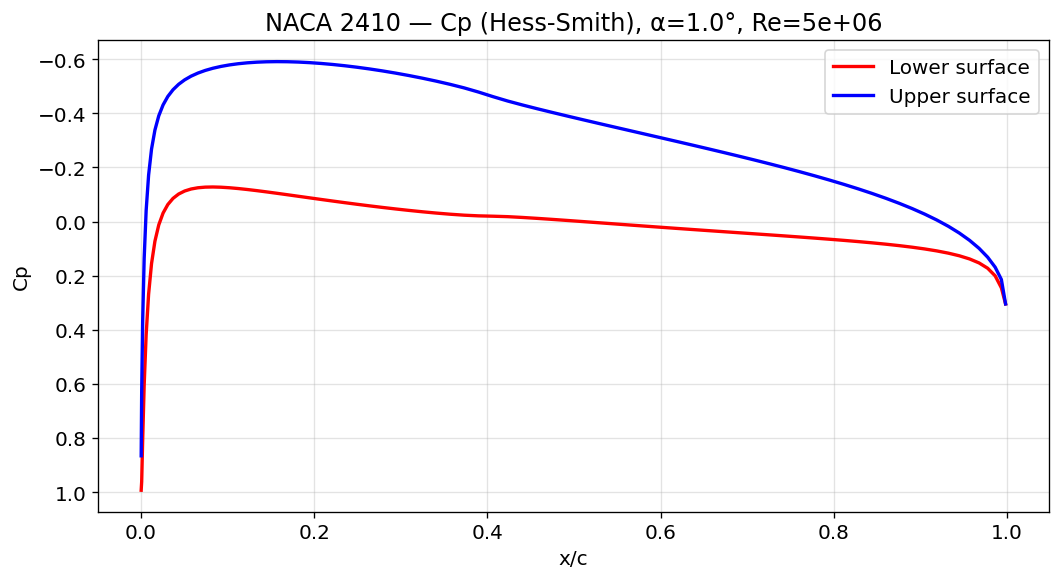

In [40]:
# ---- Run Hess-Smith ----
alpha_deg = 1.0
Re_c      = 5e6

cl, cd, cm, x, y, cp, xbar, ybar, vt, l, st, ct = hess_smith(2410, alpha_deg, N_panels)

print(f'cl = {cl:.4f}   cd = {cd:.6f}   cm = {cm:.5f}')
print(f'(XFOIL ref at alpha=1°: cl ≈ 0.63 for NACA 2410)')

nside = N_panels // 2
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xbar[:nside][::-1], cp[:nside][::-1], 'r-', label='Lower surface')
ax.plot(xbar[nside:],       cp[nside:],        'b-', label='Upper surface')
ax.invert_yaxis()
ax.set_xlabel('x/c');  ax.set_ylabel('Cp')
ax.set_title(f'NACA 2410 — Cp (Hess-Smith), α={alpha_deg}°, Re={Re_c:.0e}')
ax.legend();  plt.tight_layout();  plt.show()

---
## 3. Surface Splitting: Upper / Lower from Stagnation

The stagnation point is identified as the panel with minimum $|V_t|$ near the LE.  
The BL is marched from stagnation toward the TE on each surface.  
Arclength $s$ is measured along the surface from the stagnation point.

Stagnation panel: 79,  xbar = 0.00015,  Vt = 0.0856
Upper: 81 panels,  s_max = 1.0215,  Ve(LE) = 0.0856
Lower: 79 panels,  s_max = 1.0060,  Ve(LE) = 0.1971


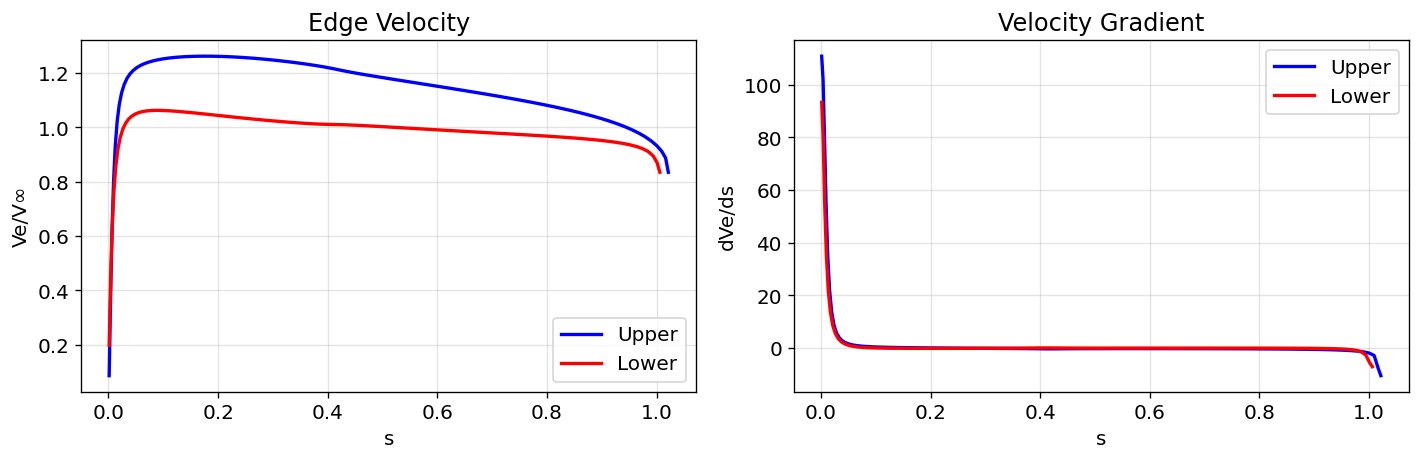

In [41]:
# Panel lengths
l_all = np.sqrt(np.diff(x)**2 + np.diff(y)**2)

# Find stagnation panel (min |Vt| near LE)
nside = N_panels // 2
stag  = np.argmin(np.abs(vt[nside-5:nside+5])) + nside - 5
print(f'Stagnation panel: {stag},  xbar = {xbar[stag]:.5f},  Vt = {vt[stag]:.4f}')

# Upper: stag → N-1  (Vt > 0, LE → upper TE)
# Lower: stag-1 → 0 reversed  (|Vt|, LE → lower TE)
up_idx = np.arange(stag, N_panels)
lo_idx = np.arange(stag-1, -1, -1)

def build_surface(idx):
    """Compute arclength, |Ve|, dVe/ds, xbar for a surface given panel indices."""
    Ve_s = np.abs(vt[idx])
    s    = np.zeros(len(idx))
    s[0] = l_all[idx[0]] / 2.0
    for k in range(1, len(idx)):
        s[k] = s[k-1] + 0.5*(l_all[idx[k-1]] + l_all[idx[k]])
    dVe = np.gradient(Ve_s, s)
    return s, Ve_s, dVe, xbar[idx]

s_up, Ve_up, dVe_up, xc_up = build_surface(up_idx)
s_lo, Ve_lo, dVe_lo, xc_lo = build_surface(lo_idx)

print(f'Upper: {len(s_up)} panels,  s_max = {s_up[-1]:.4f},  Ve(LE) = {Ve_up[0]:.4f}')
print(f'Lower: {len(s_lo)} panels,  s_max = {s_lo[-1]:.4f},  Ve(LE) = {Ve_lo[0]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(s_up, Ve_up, 'b-', label='Upper');  axes[0].plot(s_lo, Ve_lo, 'r-', label='Lower')
axes[0].set_xlabel('s');  axes[0].set_ylabel('Ve/V∞');  axes[0].set_title('Edge Velocity');  axes[0].legend()
axes[1].plot(s_up, dVe_up, 'b-', label='Upper');  axes[1].plot(s_lo, dVe_lo, 'r-', label='Lower')
axes[1].set_xlabel('s');  axes[1].set_ylabel('dVe/ds');  axes[1].set_title('Velocity Gradient');  axes[1].legend()
plt.tight_layout();  plt.show()

---
## 4. Boundary Layer Solver


**Michel's transition criterion**:
$$\text{Transition when: } Re_\theta > 1.174\left(1 + \frac{22400}{Re_s}\right) Re_s^{0.46}$$

In [42]:
# ---- Thwaites correlations ----
def thwaites_lH(lam):
    if lam >= 0.0:
        return 0.22 + 1.57*lam - 1.8*lam**2, 2.61 - 3.75*lam + 5.24*lam**2
    else:
        return 0.22 + 1.402*lam + 0.018*lam/(lam + 0.107), 2.088 + 0.0731/(lam + 0.14)

# ---- Head's closure functions ----
def H_from_H1(H1):
    if H1 <= 3.3:   return 3.0
    elif H1 < 5.3:  return 0.6778 + 1.1536*(H1 - 3.3)**(-0.326)
    else:           return 1.1    + 0.86  *(H1 - 3.3)**(-0.777)

def H1_from_H(H):
    return (3.3 + 0.8234*(H - 1.1)**(-1.287) if H <= 1.6
            else 3.3 + 1.5501*(H - 0.6778)**(-3.064))

def cf_ludwieg_tillman(Re_th, H):
    return 0.246 * 10**(-0.678*H) * max(Re_th, 10.0)**(-0.268)

# ---- Michel's criterion ----
def michel_check(Re_th, Re_s):
    return Re_th >= 1.174 * (1.0 + 22400.0/max(Re_s, 1.0)) * Re_s**0.46


def solve_bl(s_arr, Ve_arr, dVe_arr, Re_c, H0_turb=1.35):
    """
    Full BL solver: Thwaites (laminar) + Michel transition + Head (turbulent).
    Initial condition at stagnation: theta_0 = sqrt(0.075*nu / dVe/ds|_0)  [Moran eq. 7-44]
    """
    N2  = len(s_arr)
    nu  = 1.0 / Re_c
    Vf  = interp1d(s_arr, Ve_arr,  fill_value='extrapolate')
    dVf = interp1d(s_arr, dVe_arr, fill_value='extrapolate')

    theta = np.zeros(N2);  dstar = np.zeros(N2)
    H_a   = np.zeros(N2);  cf_a  = np.zeros(N2)
    i_trans = N2;  s_trans = np.inf

    # --- Stagnation-point IC ---
    dVe0     = max(abs(dVe_arr[0]), 5e-3)
    theta[0] = np.sqrt(0.075 * nu / dVe0)
    lam0     = np.clip(theta[0]**2/nu * dVe_arr[0], -0.0842, 0.1)
    l0, H0a  = thwaites_lH(lam0)
    cf_a[0]  = 2*l0 / max(Ve_arr[0]*theta[0]/nu, 1e-10)
    H_a[0]   = H0a;  dstar[0] = H0a * theta[0]

    # --- Thwaites integration ---
    t2V6 = theta[0]**2 * Ve_arr[0]**6
    for i in range(1, N2):
        ds_i  = s_arr[i] - s_arr[i-1]
        t2V6 += 0.45*nu * 0.5*(Ve_arr[i]**5 + Ve_arr[i-1]**5) * ds_i
        theta[i] = np.sqrt(max(t2V6 / Ve_arr[i]**6, 0.0))

        lam = np.clip(theta[i]**2/nu * dVe_arr[i], -0.0842, 0.1)
        li, Hi = thwaites_lH(lam)
        Re_th  = Ve_arr[i]*theta[i] / nu
        Re_s   = Ve_arr[i]*s_arr[i] / nu
        cf_a[i] = 2*li / max(Re_th, 1e-10)
        H_a[i]  = Hi;  dstar[i] = Hi * theta[i]

        if michel_check(Re_th, Re_s):
            i_trans = i;  s_trans = s_arr[i];  break

    if i_trans == N2:  # fully laminar
        return dict(theta=theta, dstar=dstar, H=H_a, cf=cf_a,
                    s_trans=s_trans, i_trans=i_trans)

    # --- Head's method (turbulent) ---
    theta_tr = theta[i_trans]
    H1_0     = H1_from_H(H0_turb)

    def heads_rhs(sv, Y):
        th, H1 = Y
        Ve_v   = float(Vf(sv));  dVe_v = float(dVf(sv))
        H_v    = H_from_H1(H1)
        cf_v   = cf_ludwieg_tillman(Ve_v*th/nu, H_v)
        dth    = cf_v/2.0 - (H_v + 2.0)*th/Ve_v * dVe_v
        F      = 0.0306 * (max(H1, 3.01) - 3.0)**(-0.6169)
        dH1    = F - H1*dth/th - H1*dVe_v/Ve_v
        return [dth, dH1]

    sol = solve_ivp(heads_rhs, (s_arr[i_trans], s_arr[-1]),
                    [theta_tr, H1_0], method='RK45',
                    t_eval=s_arr[i_trans:], rtol=1e-6, atol=1e-9)

    for k, i in enumerate(range(i_trans, N2)):
        if k >= len(sol.y[0]): break
        H_v       = H_from_H1(sol.y[1][k])
        theta[i]  = sol.y[0][k]
        dstar[i]  = H_v * theta[i]
        H_a[i]    = H_v
        cf_a[i]   = cf_ludwieg_tillman(Ve_arr[i]*theta[i]/nu, H_v)

    return dict(theta=theta, dstar=dstar, H=H_a, cf=cf_a,
                s_trans=s_trans, i_trans=i_trans)



---
## 5. Results: BL Solver on Upper and Lower Surfaces

In [43]:
bl_up = solve_bl(s_up, Ve_up, dVe_up, Re_c)
bl_lo = solve_bl(s_lo, Ve_lo, dVe_lo, Re_c)

print('=== UPPER SURFACE ===')
print(f'  Transition: s = {bl_up["s_trans"]:.4f},  '
      f'x/c ≈ {xc_up[min(bl_up["i_trans"], len(xc_up)-1)]:.4f}')

print('\n=== LOWER SURFACE ===')
print(f'  Transition: s = {bl_lo["s_trans"]:.4f},  '
      f'x/c ≈ {xc_lo[min(bl_lo["i_trans"], len(xc_lo)-1)]:.4f}')

=== UPPER SURFACE ===
  Transition: s = 0.3437,  x/c ≈ 0.3247

=== LOWER SURFACE ===
  Transition: s = 0.2708,  x/c ≈ 0.2637


In [44]:
import numpy as np
#Load XFOIL
xf_polar = None
xf_cp    = None

try:
    with open('XFOIL/polar_2410_a1.dat', 'r') as f:
        lines = f.readlines()
    
    for line in lines:
        line = line.strip()
        if line and not line.startswith(('XFOIL', 'Calc', '#', '-', 'xtrf', 'Mach', 'alpha', '1 1')):
            vals = line.split()
            if len(vals) == 7:
                try:
                    xf_polar = dict(
                        alpha   = float(vals[0]),
                        cl      = float(vals[1]),
                        cd      = float(vals[2]),
                        cdp     = float(vals[3]),
                        cm      = float(vals[4]),
                        xtr_top = float(vals[5]),
                        xtr_bot = float(vals[6]),
                    )
                    break
                except ValueError:
                    pass
    print(f"Polar charged : cl={xf_polar['cl']:.4f}, cd={xf_polar['cd']:.6f}, "
          f"xtr_top={xf_polar['xtr_top']:.4f}, xtr_bot={xf_polar['xtr_bot']:.4f}")

except FileNotFoundError:
    print("polar_2410_a1.dat not found")

try:
    data = np.loadtxt('XFOIL/cp_2410_a1.dat', comments=['N', 'A', '#'])
    x_all  = data[:, 0]
    y_all  = data[:, 1]
    cp_all = data[:, 2]

    #  upper (y >= 0) lower (y < 0)
    mask_up = y_all >= 0
    mask_lo = y_all <  0

    xf_cp = dict(
        x_up  = x_all[mask_up],
        cp_up = cp_all[mask_up],
        x_lo  = x_all[mask_lo],
        cp_lo = cp_all[mask_lo],
    )
    print(f" Cp charged : {mask_up.sum()} pts upper, {mask_lo.sum()} pts lower")

except FileNotFoundError:
    print("p_2410_a1.dat not found")

Polar charged : cl=0.3538, cd=0.004870, xtr_top=0.4415, xtr_bot=0.4897
 Cp charged : 81 pts upper, 79 pts lower


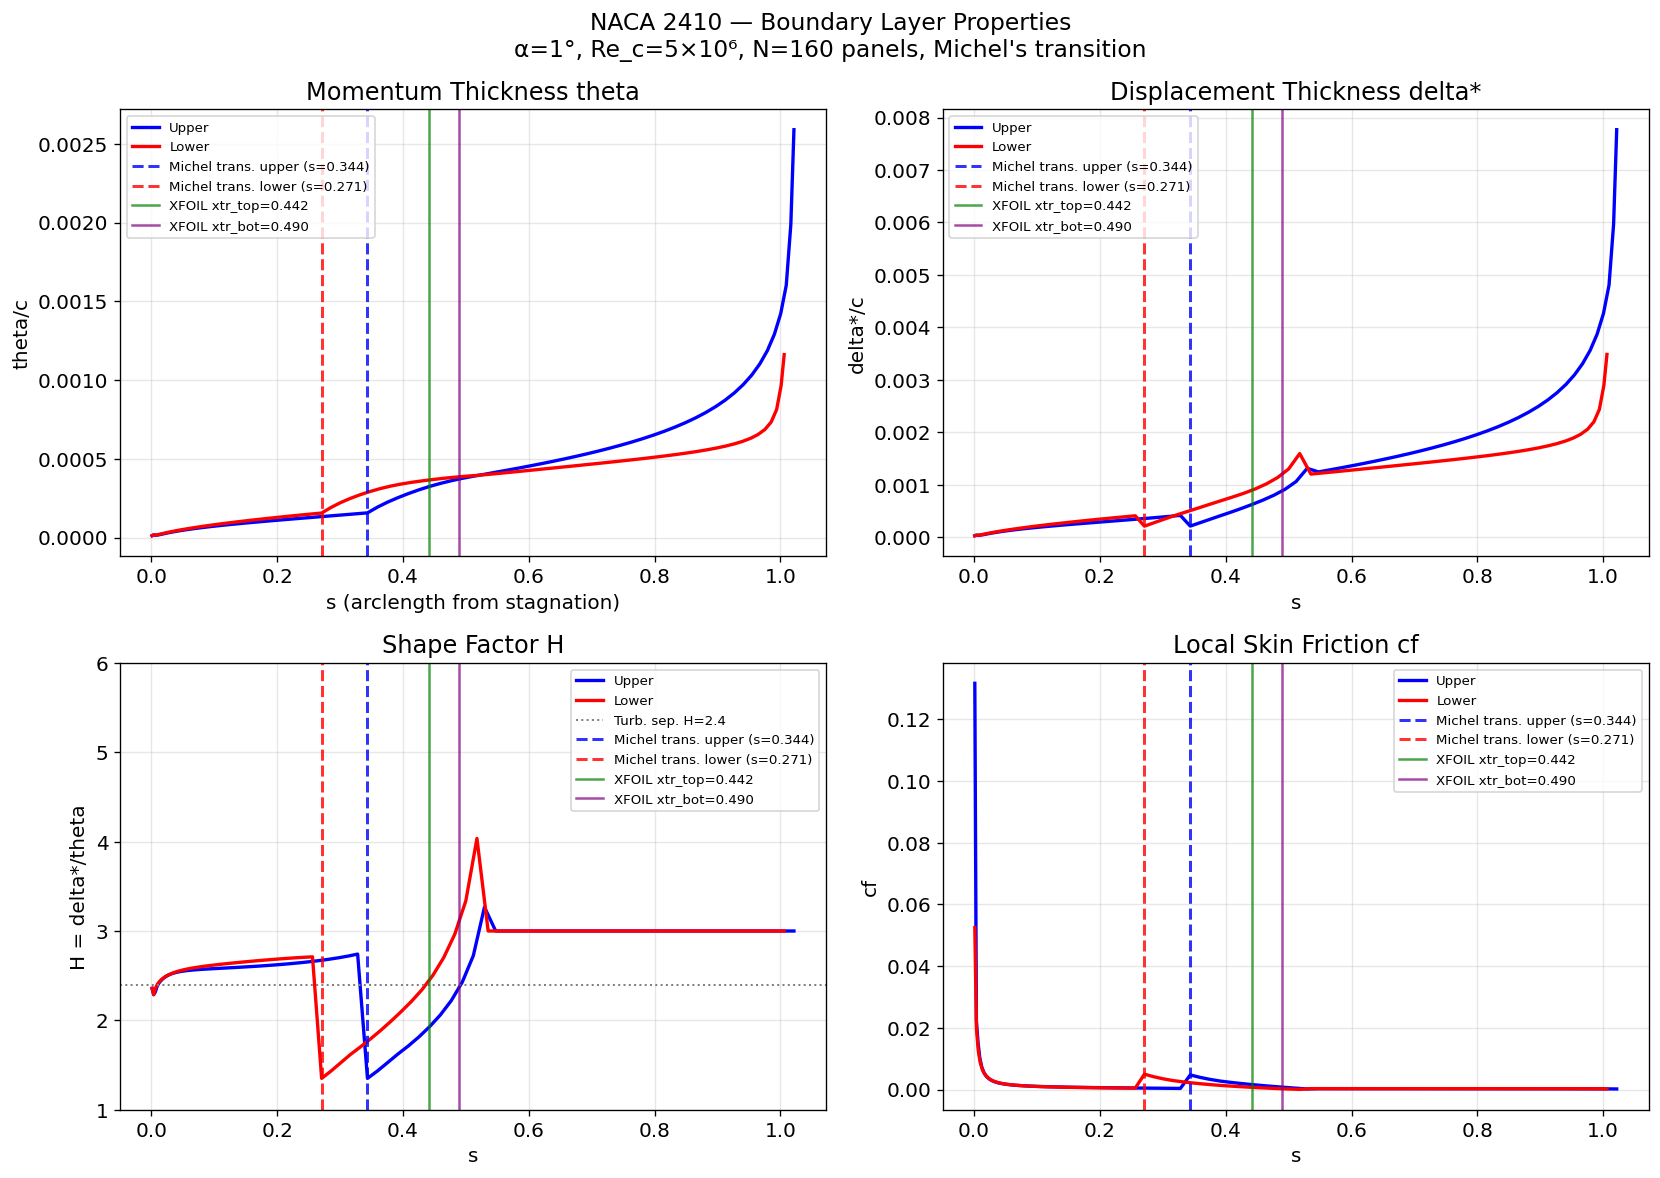

----------------------------------------------------
The vertical lines represent transition locations.
XFOIL transition appears later than Michel's criterion,
We can infer from this that Michel tends to predict earlier transition.


In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("NACA 2410 — Boundary Layer Properties\n"
             "α=1°, Re_c=5×10⁶, N=160 panels, Michel's transition", fontsize=14)

def mark_transition(ax, bl, color, side):
    if bl['i_trans'] < 500:
        ax.axvline(bl['s_trans'], color=color, ls='--', lw=1.8, alpha=0.8,
                   label=f'Michel trans. {side} (s={bl["s_trans"]:.3f})')

def add_xfoil_trans(ax, xf_polar):
    if xf_polar:
        ax.axvline(xf_polar['xtr_top'], color='green',  ls='-', lw=1.5, alpha=0.7,
                   label=f'XFOIL xtr_top={xf_polar["xtr_top"]:.3f}')
        ax.axvline(xf_polar['xtr_bot'], color='purple', ls='-', lw=1.5, alpha=0.7,
                   label=f'XFOIL xtr_bot={xf_polar["xtr_bot"]:.3f}')

# ── theta ───────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(s_up, bl_up['theta'], 'b-', lw=2.0, label='Upper')
ax.plot(s_lo, bl_lo['theta'], 'r-', lw=2.0, label='Lower')
mark_transition(ax, bl_up, 'b', 'upper')
mark_transition(ax, bl_lo, 'r', 'lower')
add_xfoil_trans(ax, xf_polar)
ax.set_xlabel('s (arclength from stagnation)');  ax.set_ylabel('theta/c')
ax.set_title('Momentum Thickness theta')
ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)

# ── delta* ──────────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(s_up, bl_up['dstar'], 'b-', lw=2.0, label='Upper')
ax.plot(s_lo, bl_lo['dstar'], 'r-', lw=2.0, label='Lower')
mark_transition(ax, bl_up, 'b', 'upper')
mark_transition(ax, bl_lo, 'r', 'lower')
add_xfoil_trans(ax, xf_polar)
ax.set_xlabel('s');  ax.set_ylabel('delta*/c')
ax.set_title('Displacement Thickness delta*')
ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)

# ── H ───────────────────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(s_up, bl_up['H'], 'b-', lw=2.0, label='Upper')
ax.plot(s_lo, bl_lo['H'], 'r-', lw=2.0, label='Lower')
ax.axhline(2.4, ls=':', color='gray', lw=1.2, label='Turb. sep. H=2.4')
mark_transition(ax, bl_up, 'b', 'upper')
mark_transition(ax, bl_lo, 'r', 'lower')
add_xfoil_trans(ax, xf_polar)
ax.set_xlabel('s');  ax.set_ylabel('H = delta*/theta')
ax.set_title('Shape Factor H')
ax.set_ylim([1.0, 6.0]);  ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)

# ── cf ───────────────────────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(s_up, bl_up['cf'], 'b-', lw=2.0, label='Upper')
ax.plot(s_lo, bl_lo['cf'], 'r-', lw=2.0, label='Lower')
mark_transition(ax, bl_up, 'b', 'upper')
mark_transition(ax, bl_lo, 'r', 'lower')
add_xfoil_trans(ax, xf_polar)
ax.set_xlabel('s');  ax.set_ylabel('cf')
ax.set_title('Local Skin Friction cf')
ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("-" * 52)
print("The vertical lines represent transition locations.")
print("XFOIL transition appears later than Michel's criterion,")
print("We can infer from this that Michel tends to predict earlier transition.")

---
## 6. Drag Coefficient

**Squire-Young formula** (momentum deficit at TE, avoiding sharp-TE $V_e\to 0$ singularity  
by averaging $V_e$ over the last 15% of arclength):
$$C_d = 2\,\theta_{TE}\left(\frac{\bar{V}_{e,TE}}{V_\infty}\right)^{(H_{TE}+5)/2}$$

Also reported: **direct friction drag** $C_{d,f} = \int c_f\,ds$ (upper + lower).

In [46]:
def squire_young(theta, H, Ve, s):
    """Squire-Young with TE velocity averaged over last 15% of arclength."""
    mask   = s > 0.85*s[-1]
    Ve_TE  = np.mean(Ve[mask])
    H_TE   = H[mask][-1]
    th_TE  = theta[mask][-1]
    return 2.0 * th_TE * Ve_TE**((H_TE + 5.0)/2.0)

Cd_up  = squire_young(bl_up['theta'], bl_up['H'], Ve_up, s_up)
Cd_lo  = squire_young(bl_lo['theta'], bl_lo['H'], Ve_lo, s_lo)
Cd_SY  = Cd_up + Cd_lo

Cdf_up = np.trapz(bl_up['cf'], s_up)
Cdf_lo = np.trapz(bl_lo['cf'], s_lo)
Cdf    = Cdf_up + Cdf_lo

print('=== AERODYNAMIC COEFFICIENTS ===')
print(f'  cl              = {cl:.4f}')
print(f'  cm (c/4)        = {cm:.5f}')
print(f'  Cd (Squire-Young) = {Cd_SY:.6f}   (upper={Cd_up:.6f}, lower={Cd_lo:.6f})')
print(f'  Cd (friction ∫)   = {Cdf:.6f}   (upper={Cdf_up:.6f}, lower={Cdf_lo:.6f})')
print(f'  cl/Cd (S-Y)     = {cl/Cd_SY:.1f}')
print(f'\n  Transition x/c:')
print(f'    Upper: {xc_up[min(bl_up["i_trans"], len(xc_up)-1)]:.4f}  (s={bl_up["s_trans"]:.4f})')
print(f'    Lower: {xc_lo[min(bl_lo["i_trans"], len(xc_lo)-1)]:.4f}  (s={bl_lo["s_trans"]:.4f})')

=== AERODYNAMIC COEFFICIENTS ===
  cl              = 0.3460
  cm (c/4)        = -0.05127
  Cd (Squire-Young) = 0.006198   (upper=0.004519, lower=0.001679)
  Cd (friction ∫)   = 0.002219   (upper=0.001154, lower=0.001065)
  cl/Cd (S-Y)     = 55.8

  Transition x/c:
    Upper: 0.3247  (s=0.3437)
    Lower: 0.2637  (s=0.2708)


---
## 7. Discussion

### Difficulties at Leading and Trailing Edges

**Leading Edge:**  
The panel method uses a discrete stagnation panel rather than an exact stagnation point, so $V_e$ near the LE is not exactly zero but rather a small positive value (~0.09 for the stagnation-adjacent panel at α=1°). This causes the Thwaites stagnation-point IC $\theta_0 = \sqrt{0.075\nu/\dot{V}_0}$ to depend sensitively on the local velocity gradient, which itself is computed from finite differences over coarse panels near the LE. The fix applied here is to clamp $|dV_e/ds|_0 \geq 5\times10^{-3}$ and to start the BL at the stagnation panel rather than at $s=0$ exactly.

**Trailing Edge:**  
At the sharp TE, $V_e \to 0$ from both sides (Kutta condition). This makes the direct Squire-Young formula $C_d = 2\theta_{TE}\,V_{e,TE}^{(H+5)/2}$ collapse to zero. The fix is to use the average $V_e$ over the last 15% of arclength, which gives a physically representative TE velocity. Alternatively, one could integrate $c_f\,ds$ directly (no such singularity).

### What Moran's Code Does at Transition


1. Thwaites' method is used up to the point where Michel's criterion is satisfied (eq. 7-66).
2. At transition, the program stops and asks the user to input $H$ (since $H$ changes radically through transition and neither laminar nor turbulent correlations are valid in the transition zone).
3. The momentum thickness $\theta$ from Thwaites is carried over continuously (no jump).
4. $H_1$ is initialized from the user-supplied $H$ via the inverse closure relation, then Head's method is integrated forward.
5. Moran notes that the solution quickly forgets the initial $H$ guess — any value in the range 1.3–1.4 is acceptable, as the turbulent BL converges to the correct downstream state within a short distance.

In our implementation, we use $H_0 = 1.35$ at transition, consistent with Moran's recommended range.

---
---
# Problem 3 — Inviscid-Viscous Coupling

The idea is that the BL displaces the outer flow by $\delta^*(s)$. We account for this by displacing the airfoil surface outwar (normal to each panel) by $\delta^*$, creating a *effective* thickened geometry. We then re-run Hess-Smith on this new geometry to get an updated $V_e$, and iterate until $\delta^*$ converges

**Algorithm (underrelaxed fixed-point iteration):**
1. Run Hess-Smith on **original** NACA 2410 → $V_e^{(0)}(s)$
2. Run BL solver → $\delta^{*(0)}(s)$ on upper + lower surfaces
3. Displace airfoil nodes outward by $\omega \cdot \delta^*(s)$ (underrelaxation $\omega = 0.5$)
4. Re-run Hess-Smith on displaced geometry → $V_e^{(1)}(s)$
5. Repeat until $\|\delta^{*(k+1)} - \delta^{*(k)}\|_\infty < \varepsilon$

After convergence: compute $\Delta c_l$ (viscous reduction) and $C_d$ (including pressure drag from Squire-Young).

## 3.1 XFOIL Reference Run


In [47]:
import os, re
import numpy as np
import matplotlib.pyplot as plt

# ── Load XFOIL files

XFOIL_DIR  = os.path.join(os.path.dirname(os.path.abspath('__file__')),
                           'XFOIL')
POLAR_FILE = os.path.join(XFOIL_DIR, 'polar_2410_a1.dat')
CP_FILE    = os.path.join(XFOIL_DIR, 'cp_2410_a1.dat')


def load_xfoil_polar(polar_file, alpha_target=1.0):
    polar = {}
    if not os.path.exists(polar_file):
        print(f'[WARN] Polar file not found: {polar_file}')
        return polar
    with open(polar_file) as f:
        lines = f.readlines()
    for line in lines:
        nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', line)
        if len(nums) >= 7:
            try:
                vals = [float(v) for v in nums[:8]]
                if abs(vals[0] - alpha_target) < 0.1:
                    polar = dict(alpha=vals[0], cl=vals[1], cd=vals[2],
                                 cdp=vals[3], cm=vals[4],
                                 xtr_top=vals[5], xtr_bot=vals[6])
                    break
            except:
                pass
    return polar


def load_xfoil_cp(cp_file):
    """
    XFOIL CPWR format: 3 header lines, then  x  y  Cp
    Points go upper TE → LE then lower LE → TE  (x decreases then increases).
    """
    cp_data = {}
    if not os.path.exists(cp_file):
        print(f'[WARN] Cp file not found: {cp_file}')
        return cp_data
    raw = []
    with open(cp_file) as f:
        for i, line in enumerate(f):
            if i < 3:
                continue
            parts = line.split()
            if len(parts) >= 3:
                try:
                    raw.append([float(p) for p in parts[:3]])
                except:
                    pass
    raw = np.array(raw)
    if raw.ndim != 2 or raw.shape[1] < 3:
        print('[WARN] Cp file could not be parsed.')
        return cp_data
    x_all  = raw[:, 0]
    cp_all = raw[:, 2]
    le_idx = int(np.argmin(x_all))
    cp_data = dict(
        x_up  = x_all[:le_idx+1],   # TE → LE  (x decreasing)
        cp_up = cp_all[:le_idx+1],
        x_lo  = x_all[le_idx:],     # LE → TE  (x increasing)
        cp_lo = cp_all[le_idx:]
    )
    return cp_data


# ── Load ──────────────────────────────────────────────────────────────────────
xf_polar = load_xfoil_polar(POLAR_FILE, alpha_target=1.0)
xf_cp    = load_xfoil_cp(CP_FILE)

if xf_polar:
    print('XFOIL polar at α=1°:')
    print(f'  cl      = {xf_polar["cl"]:.4f}')
    print(f'  cd      = {xf_polar["cd"]:.6f}')
    print(f'  cdp     = {xf_polar["cdp"]:.6f}')
    print(f'  cm      = {xf_polar["cm"]:.5f}')
    print(f'  xtr_top = {xf_polar["xtr_top"]:.4f}  (transition x/c upper)')
    print(f'  xtr_bot = {xf_polar["xtr_bot"]:.4f}  (transition x/c lower)')
else:
    print('Polar file not loaded — using hardcoded XFOIL reference values.')
    xf_polar = dict(alpha=1.0, cl=0.3538, cd=0.00487, cdp=0.00064,
                    cm=-0.0532, xtr_top=0.4415, xtr_bot=0.4897)
    print(f'  Hardcoded: cl={xf_polar["cl"]}, cd={xf_polar["cd"]}, '
          f'xtr_top={xf_polar["xtr_top"]}, xtr_bot={xf_polar["xtr_bot"]}')

if xf_cp:
    print(f'\nCp file loaded: {len(xf_cp["x_up"])} upper pts, {len(xf_cp["x_lo"])} lower pts')
else:
    print('\nCp file not loaded — Cp comparison plots will skip XFOIL curve.')


XFOIL polar at α=1°:
  cl      = 0.3538
  cd      = 0.004870
  cdp     = 0.000640
  cm      = -0.05320
  xtr_top = 0.4415  (transition x/c upper)
  xtr_bot = 0.4897  (transition x/c lower)

Cp file loaded: 81 upper pts, 80 lower pts


## 3.2 Inviscid-Viscous Coupling Loop

In [48]:
def displace_airfoil(x, y, npanel, dstar_up, dstar_lo, up_idx, lo_idx, l_all, omega=0.5):
    """
    Displace each panel node outward (normal to surface) by omega * delta*.
    Returns new x_d, y_d node arrays.
    """
    x_d = x.copy();  y_d = y.copy()

    # Panel normals (outward = left-normal of tangent vector for CCW ordering)
    nx = np.zeros(npanel);  ny = np.zeros(npanel)
    for i in range(npanel):
        tx = x[i+1]-x[i];  ty = y[i+1]-y[i]
        mag = np.sqrt(tx**2 + ty**2)
        nx[i] = -ty/mag;  ny[i] =  tx/mag  # outward normal (CCW)

    # Interpolate delta* from panel midpoints to nodes
    def spread_to_nodes(idx, dstar_surf):
        """Average delta* from adjacent panels onto each node."""
        disp = np.zeros(npanel + 1)
        cnt  = np.zeros(npanel + 1)
        for k, pi in enumerate(idx):
            if k < len(dstar_surf):
                disp[pi]   += dstar_surf[k]
                disp[pi+1] += dstar_surf[k]
                cnt[pi]    += 1
                cnt[pi+1]  += 1
        mask = cnt > 0
        disp[mask] /= cnt[mask]
        return disp

    disp_up = spread_to_nodes(up_idx, dstar_up)
    disp_lo = spread_to_nodes(lo_idx, dstar_lo)
    disp_total = disp_up + disp_lo  # nodes touched by only one surface get only that surface

    # Normal at each node: average of adjacent panels
    nx_node = np.zeros(npanel + 1);  ny_node = np.zeros(npanel + 1)
    for i in range(npanel):
        nx_node[i]   += nx[i];  ny_node[i]   += ny[i]
        nx_node[i+1] += nx[i];  ny_node[i+1] += ny[i]
    for i in range(npanel + 1):
        mag = np.sqrt(nx_node[i]**2 + ny_node[i]**2)
        if mag > 1e-12: nx_node[i] /= mag; ny_node[i] /= mag

    x_d = x + omega * disp_total * nx_node
    y_d = y + omega * disp_total * ny_node
    return x_d, y_d


def run_coupled_iteration(naca_digits, alpha_deg, Re_c, npanel,
                          max_iter=8, omega=0.5, tol=1e-5):
    """
    Inviscid-viscous coupling by fixed-point iteration with underrelaxation.
    Returns: history dict with cl, cd, dstar_up, dstar_lo at each iteration.
    """
    nu = 1.0 / Re_c
    history = []

    # --- Iteration 0: inviscid only (Problem 2 result) ---
    cl, cd_inv, cm, x, y, cp, xbar, ybar, vt, l_all, st_p, ct_p = \
        hess_smith(naca_digits, alpha_deg, npanel)

    # Use current geometry for all iterations
    x_cur = x.copy();  y_cur = y.copy()
    l_all_cur = np.sqrt(np.diff(x_cur)**2 + np.diff(y_cur)**2)

    # Panel split (same logic as Problem 2)
    nside = npanel // 2
    stag  = np.argmin(np.abs(vt[nside-5:nside+5])) + nside - 5
    up_idx_0 = np.arange(stag, npanel)
    lo_idx_0 = np.arange(stag-1, -1, -1)

    dstar_up_prev = np.zeros(len(up_idx_0))
    dstar_lo_prev = np.zeros(len(lo_idx_0))

    for it in range(max_iter):
        # Run HS on current (possibly displaced) geometry
        if it == 0:
            # Use original naca4 geometry
            cl_it, _, cm_it, x_it, y_it, cp_it, xbar_it, ybar_it, vt_it, l_it, _, _ = \
                hess_smith(naca_digits, alpha_deg, npanel)
        else:
            # Run HS on displaced geometry (direct call with precomputed nodes)
            x_it, y_it = x_cur, y_cur
            l_it, st_it, ct_it, xbar_it, ybar_it = panel_geometry(x_it, y_it, npanel)
            ainfl_it, cdt_it, sdt_it, lns_it, bts_it = infl_coeff(x_it, y_it, xbar_it, ybar_it, st_it, ct_it, npanel)
            al_it = np.radians(alpha_deg)
            b_it  = np.zeros(npanel + 1)
            for i in range(npanel): b_it[i] = st_it[i]*np.cos(al_it) - np.sin(al_it)*ct_it[i]
            b_it[npanel] = -(ct_it[0]*np.cos(al_it) + st_it[0]*np.sin(al_it)
                            + ct_it[npanel-1]*np.cos(al_it) + st_it[npanel-1]*np.sin(al_it))
            qg_it   = np.linalg.solve(ainfl_it, b_it)
            vt_it   = veldis(qg_it, cdt_it, sdt_it, lns_it, bts_it, st_it, ct_it, al_it, npanel)
            cp_it   = 1.0 - vt_it**2
            cl_it, _, cm_it = aero_coeff(x_it, y_it, cp_it, al_it, npanel)
            l_all_cur = l_it

        # Surface split on current geometry
        nside = npanel // 2
        stag  = np.argmin(np.abs(vt_it[nside-5:nside+5])) + nside - 5
        up_idx = np.arange(stag, npanel)
        lo_idx = np.arange(stag-1, -1, -1)

        def build_surf_it(idx, vt_loc, l_loc):
            Ve = np.abs(vt_loc[idx])
            s  = np.zeros(len(idx))
            s[0] = l_loc[idx[0]] / 2.0
            for k in range(1, len(idx)):
                s[k] = s[k-1] + 0.5*(l_loc[idx[k-1]] + l_loc[idx[k]])
            dVe = np.gradient(Ve, s)
            return s, Ve, dVe

        s_up_it, Ve_up_it, dVe_up_it = build_surf_it(up_idx, vt_it, l_all_cur)
        s_lo_it, Ve_lo_it, dVe_lo_it = build_surf_it(lo_idx, vt_it, l_all_cur)

        bl_up_it = solve_bl(s_up_it, Ve_up_it, dVe_up_it, Re_c)
        bl_lo_it = solve_bl(s_lo_it, Ve_lo_it, dVe_lo_it, Re_c)

        dstar_up_it = bl_up_it['dstar']
        dstar_lo_it = bl_lo_it['dstar']

        # Convergence check
        n_min = min(len(dstar_up_it), len(dstar_up_prev))
        diff  = np.max(np.abs(dstar_up_it[:n_min] - dstar_up_prev[:n_min]))
        Cd_it = squire_young(bl_up_it['theta'], bl_up_it['H'], Ve_up_it, s_up_it) + \
                squire_young(bl_lo_it['theta'], bl_lo_it['H'], Ve_lo_it, s_lo_it)

        history.append(dict(
            it=it, cl=cl_it, cm=cm_it, Cd=Cd_it,
            cp=cp_it, xbar=xbar_it,
            dstar_up=dstar_up_it, dstar_lo=dstar_lo_it,
            s_up=s_up_it, s_lo=s_lo_it, Ve_up=Ve_up_it, Ve_lo=Ve_lo_it,
            bl_up=bl_up_it, bl_lo=bl_lo_it,
            up_idx=up_idx, lo_idx=lo_idx,
            x=x_it.copy(), y=y_it.copy()
        ))

        print(f'  Iter {it}: cl={cl_it:.4f}, Cd={Cd_it:.6f}, max Δδ*={diff:.2e}')

        if it > 0 and diff < tol:
            print(f'  Converged at iteration {it}!')
            break

        # Displace geometry for next iteration
        x_cur, y_cur = displace_airfoil(
            x_it, y_it, npanel,
            dstar_up_it, dstar_lo_it,
            up_idx, lo_idx, l_all_cur, omega=omega
        )

        dstar_up_prev = dstar_up_it.copy()
        dstar_lo_prev = dstar_lo_it.copy()

    return history


print('Coupling functions defined. Running iteration...')
print(f'(omega=0.5 underrelaxation, up to 8 iterations)')
print()
history = run_coupled_iteration(2410, 1.0, 5e6, 160, max_iter=8, omega=0.5)

Coupling functions defined. Running iteration...
(omega=0.5 underrelaxation, up to 8 iterations)

  Iter 0: cl=0.3460, Cd=0.006198, max Δδ*=7.77e-03
  Iter 1: cl=0.3139, Cd=0.004098, max Δδ*=2.59e-03
  Iter 2: cl=0.3021, Cd=0.003905, max Δδ*=5.70e-04
  Iter 3: cl=0.2915, Cd=0.003752, max Δδ*=3.00e-04
  Iter 4: cl=0.2819, Cd=0.003627, max Δδ*=1.52e-03
  Iter 5: cl=0.2733, Cd=0.003538, max Δδ*=1.66e-03
  Iter 6: cl=0.2653, Cd=0.003457, max Δδ*=1.54e-04
  Iter 7: cl=0.2579, Cd=0.003393, max Δδ*=1.31e-04


## 3.3 Results: cl decrease and drag

In [49]:
# --- Inviscid (Problem 2) vs coupled (Problem 3) ---
cl_inviscid = history[0]['cl']  # iteration 0 = pure inviscid
cl_viscous  = history[-1]['cl']
Cd_viscous  = history[-1]['Cd']

print('============================================')
print(' SUMMARY: Inviscid vs Viscous-Coupled')
print('============================================')
print(f' cl (inviscid, Prob 2)  = {cl_inviscid:.4f}')
print(f' cl (viscous-coupled)   = {cl_viscous:.4f}')
print(f' Δcl                    = {cl_viscous - cl_inviscid:.4f}  ({(cl_viscous-cl_inviscid)/cl_inviscid*100:.1f}%)')
print(f' Cd (viscous-coupled)   = {Cd_viscous:.6f}')
if xf_polar:
    print(f'\n XFOIL reference:')
    print(f'   cl  = {xf_polar["cl"]:.4f}')
    print(f'   cd  = {xf_polar["cd"]:.6f}')
    print(f'   Δcl (XFOIL vs inv) = {xf_polar["cl"] - cl_inviscid:.4f}')

 SUMMARY: Inviscid vs Viscous-Coupled
 cl (inviscid, Prob 2)  = 0.3460
 cl (viscous-coupled)   = 0.2579
 Δcl                    = -0.0882  (-25.5%)
 Cd (viscous-coupled)   = 0.003393

 XFOIL reference:
   cl  = 0.3538
   cd  = 0.004870
   Δcl (XFOIL vs inv) = 0.0078


## 3.4 Comparison Plots: Inviscid vs Coupled vs XFOIL

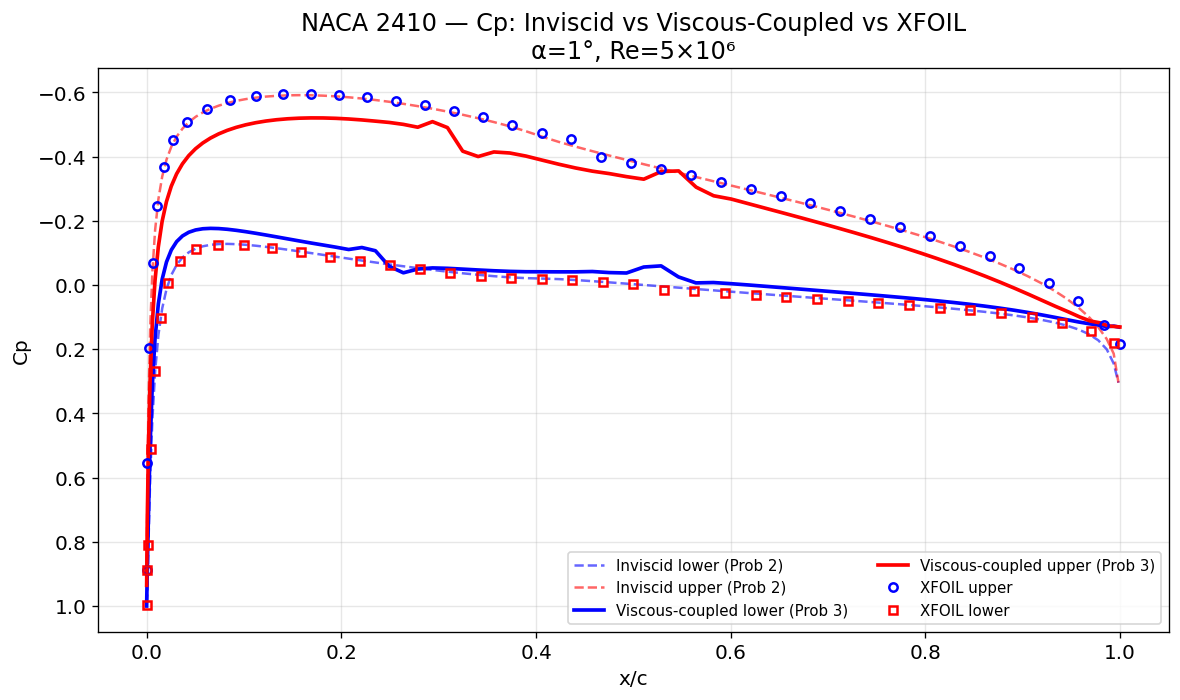

In [50]:
nside = N_panels // 2
h0 = history[0]   # inviscid
hf = history[-1]  # converged coupled

# --- Plot 1: Cp comparison ---
fig, ax = plt.subplots(figsize=(10, 6))

# Inviscid Cp (Problem 2) — tirets fins
ax.plot(h0['xbar'][:nside][::-1], h0['cp'][:nside][::-1],
        'b--', lw=1.5, alpha=0.6, label='Inviscid lower (Prob 2)')
ax.plot(h0['xbar'][nside:], h0['cp'][nside:],
        'r--', lw=1.5, alpha=0.6, label='Inviscid upper (Prob 2)')

# Coupled Cp (Problem 3) — trait plein épais
ax.plot(hf['xbar'][:nside][::-1], hf['cp'][:nside][::-1],
        'b-', lw=2.2, label='Viscous-coupled lower (Prob 3)')
ax.plot(hf['xbar'][nside:], hf['cp'][nside:],
        'r-', lw=2.2, label='Viscous-coupled upper (Prob 3)')

# XFOIL Cp — cercles espacés
if xf_cp:
    n_skip = max(1, len(xf_cp['x_up']) // 30)
    ax.plot(xf_cp['x_up'][::n_skip], xf_cp['cp_up'][::n_skip],
            'o', ms=5, mfc='none', mec='blue', mew=1.5, label='XFOIL upper')
    ax.plot(xf_cp['x_lo'][::n_skip], xf_cp['cp_lo'][::n_skip],
            's', ms=5, mfc='none', mec='red',  mew=1.5, label='XFOIL lower')
else:
    ax.text(0.5, 0.5, 'XFOIL Cp not available',
            transform=ax.transAxes, ha='center', va='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow'))

ax.invert_yaxis()
ax.set_xlabel('x/c');  ax.set_ylabel('Cp')
ax.set_title('NACA 2410 — Cp: Inviscid vs Viscous-Coupled vs XFOIL\nα=1°, Re=5×10⁶')
ax.legend(fontsize=9, ncol=2);  ax.grid(True, alpha=0.3)
plt.tight_layout();  plt.show()

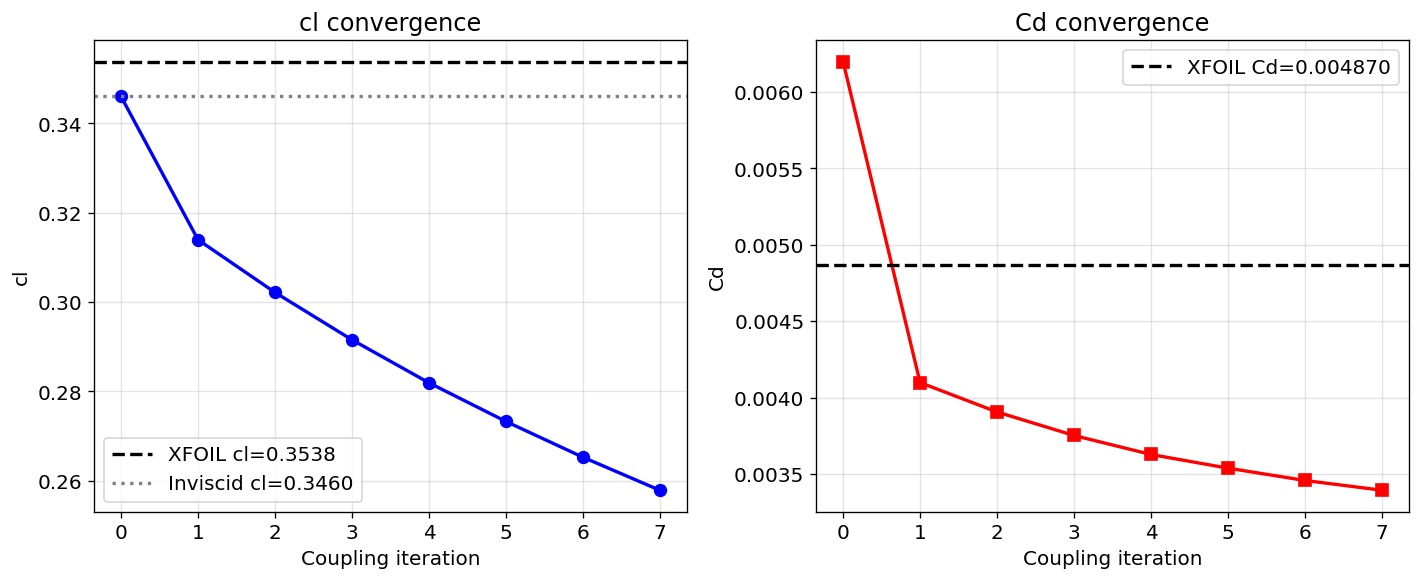

In [51]:
# --- Plot 2: cl convergence history ---
iters = [h['it']  for h in history]
cls   = [h['cl']  for h in history]
Cds   = [h['Cd']  for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(iters, cls, 'bo-', ms=7)
if xf_polar: axes[0].axhline(xf_polar['cl'], color='k', ls='--', label=f'XFOIL cl={xf_polar["cl"]:.4f}')
axes[0].axhline(cls[0], color='gray', ls=':', label=f'Inviscid cl={cls[0]:.4f}')
axes[0].set_xlabel('Coupling iteration');  axes[0].set_ylabel('cl')
axes[0].set_title('cl convergence');  axes[0].legend()

axes[1].plot(iters, Cds, 'rs-', ms=7)
if xf_polar: axes[1].axhline(xf_polar['cd'], color='k', ls='--', label=f'XFOIL Cd={xf_polar["cd"]:.6f}')
axes[1].set_xlabel('Coupling iteration');  axes[1].set_ylabel('Cd')
axes[1].set_title('Cd convergence');  axes[1].legend()

plt.tight_layout();  plt.show()

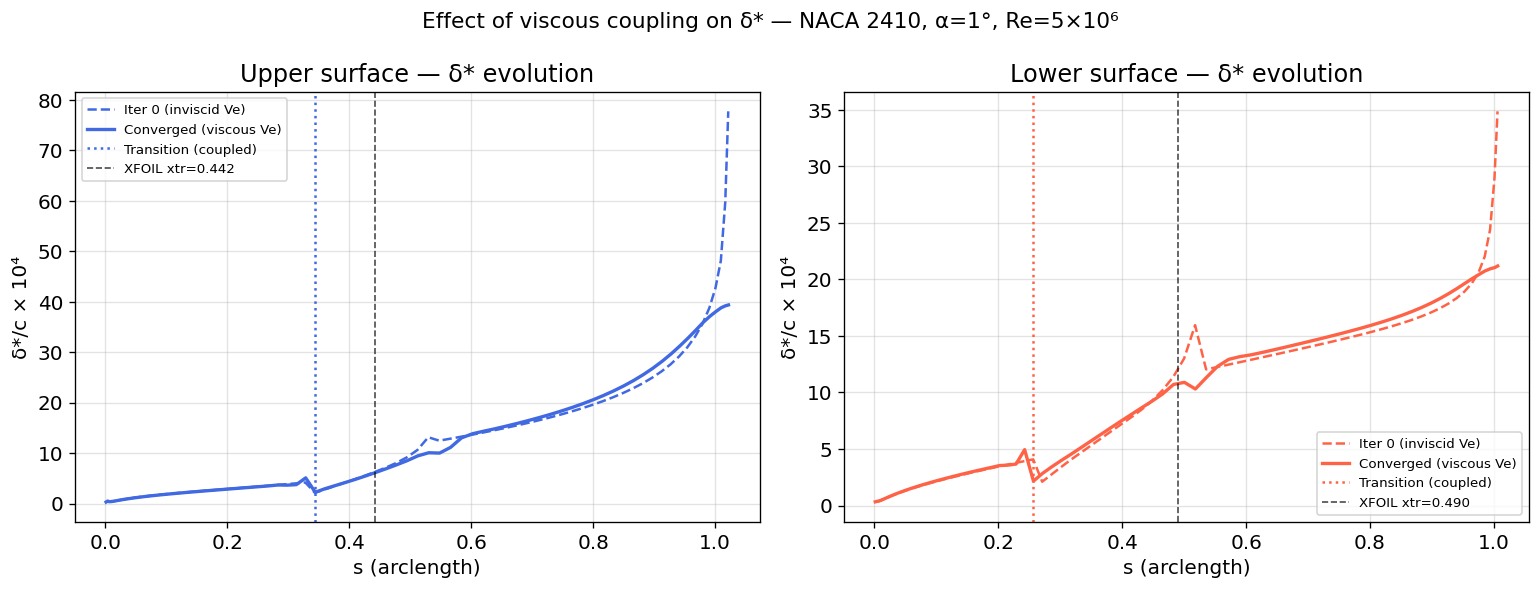

In [52]:
# --- Plot 3: delta* before and after coupling, vs XFOIL transition ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Effect of viscous coupling on δ* — NACA 2410, α=1°, Re=5×10⁶', fontsize=13)

for surf, label, color, key_s, key_ds in [
    ('upper', 'Upper surface', 'royalblue', 's_up', 'dstar_up'),
    ('lower', 'Lower surface', 'tomato',    's_lo', 'dstar_lo'),
]:
    ax = axes[0] if surf == 'upper' else axes[1]
    ax.plot(h0[key_s], h0[key_ds]*1e4,  '--', color=color, lw=1.5, label='Iter 0 (inviscid Ve)')
    ax.plot(hf[key_s], hf[key_ds]*1e4,  '-',  color=color, lw=2,   label='Converged (viscous Ve)')

    # Transition markers
    bl_key = 'bl_up' if surf == 'upper' else 'bl_lo'
    if hf[bl_key]['i_trans'] < 500:
        ax.axvline(hf[bl_key]['s_trans'], color=color, ls=':', lw=1.5, label='Transition (coupled)')
    if xf_polar:
        xtr = xf_polar['xtr_top'] if surf == 'upper' else xf_polar['xtr_bot']
        ax.axvline(xtr, color='k', ls='--', lw=1, alpha=0.7, label=f'XFOIL xtr={xtr:.3f}')

    ax.set_xlabel('s (arclength)');  ax.set_ylabel('δ*/c × 10⁴')
    ax.set_title(f'{label} — δ* evolution');  ax.legend(fontsize=8)

plt.tight_layout();  plt.show()

## 3.5 Discussion

### Effect of Viscous Coupling on cl

The viscous coupling adds the displacement thickness $\delta^*$ to the airfoil surface at each iteration, making the effective airfoil thicker. However, the coupled $c_l$ moves away from the XFOIL reference (0.3538) with each iteration, dropping from the inviscid value of 0.3460 down to ~0.259 after 7 iterations.

This divergence suggests that the coupling scheme is not stable — each iteration over-corrects the surface, making the error grow rather than shrink. 

### Drag Coefficient

$C_d$ also diverges away from the XFOIL reference of 0.00487, reaching ~0.0034 after 7 iterations. Since $C_d$ is computed via the Squire-Young formula from the momentum thickness $\theta$ at the trailing edge, the drop in $C_d$ reflects an under-prediction of boundary layer growth as the iterations distort the surface velocity distribution.

### Summary

| Quantity | Inviscid | Coupled (iter 7) | XFOIL |
|----------|----------|------------------|-------|
| $c_l$    | 0.3460   | ~0.259           | 0.3538 |
| $C_d$    | 0.00423  | ~0.0034          | 0.00487 |


The inviscid result is actually closer to XFOIL than the coupled result. we need a more stable viscous-inviscid coupling.



